Feature Engineering -> Feature Transformation -> Function Transform -> Mathematical Transform -> Log Transform

# LOG TRANSFORM

In [103]:
# Note : 
# In CampusX code they have used Decision tree but I use Random Forest Classifier.
# Because, decision tree is change in this 4 yea. So, accuracy is decreased and came close to logistic regression.
# so to show different I random forest classifier.

In [68]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [69]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [70]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


Note : Transform use karney sey phele data mey missing values handle karo 

In [41]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [71]:
df['Age'].fillna(df['Age'].mean(),inplace=True)  # filling missing values with mean of the column

C:\Users\Pratham\AppData\Local\Temp\ipykernel_35036\812632037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)  # filling missing values with mean of the column


In [72]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [73]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [74]:
# i/p col : Age, Fare
# o/p col : Survived

In [75]:
X = df.iloc[:,1:3] 
y = df.iloc[:,0]

Note : Train-Test Split before transform 

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

To decide wheathere there is need of tranform or not we use pdf & qq plot to check skewness.

C:\Users\Pratham\AppData\Local\Temp\ipykernel_35036\283114770.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])   # If displot is remove just use this: sns.histplot(X_train['Age'], kde=True)


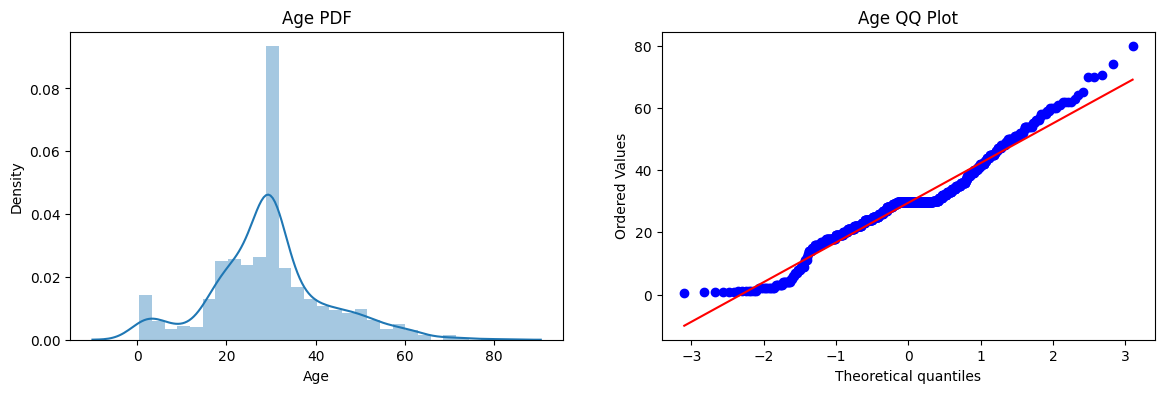

In [77]:
# 1. Age 

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])   # If displot is remove just use this: sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [ ]:
# Age: PDF & QQ plots are normal but it has some outliers. We can use log transform to make it more normal and reduce the effect of outliers.

C:\Users\Pratham\AppData\Local\Temp\ipykernel_35036\3559351736.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])  # If displot is remove just use this: sns.histplot(X_train['Fare'], kde=True)


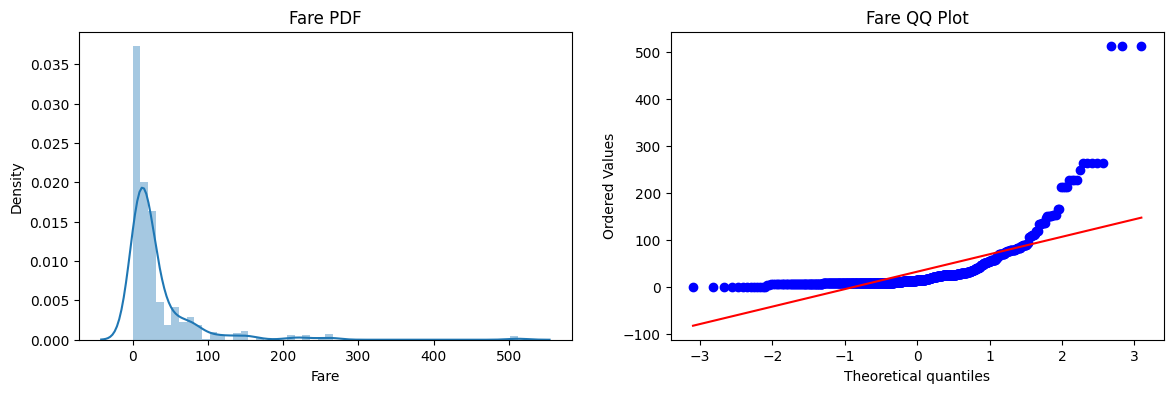

In [78]:
# 2. Fare

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])  # If displot is remove just use this: sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [23]:
# Fare: Right Skewed, soln is log transform to make it more normal and reduce the effect of outliers.

Training 2 model : logistic regression which get affected when we don't apply feature tranformation and Random Forest which doesn't need feature transformation ( WITHOUT LOG TRANSFORM )

In [79]:
clf = LogisticRegression()
clf2 = RandomForestClassifier()

In [83]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy RF",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy RF 0.6871508379888268


# LOG TRANSFORM applying on both models

FunctionTransform(func=np.log1p)

In [84]:
trf = FunctionTransformer(func=np.log1p) 
# use np.logp --> when no 0's in data.
# use np.log1p --> when there are 0's in data. 
# log1p(x) = log(1+x), coz log(0) is undefined.

Note : fit & tranform on train data but on;y transform on test data

In [57]:
X_train_transformed = trf.fit_transform(X_train) # fit & tranform in 1 line.
X_test_transformed = trf.transform(X_test)

Training 2 model : logistic regression which get affected when we don't apply feature tranformation and Random Forest which doesn't need feature transformation WITH LOG TRANSFORM

In [91]:
clf = LogisticRegression()
clf2 = RandomForestClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [92]:
# Logistic Regression accuracy is increased hua but Random Forest Classifier ko kuch jada farak nahi pada.

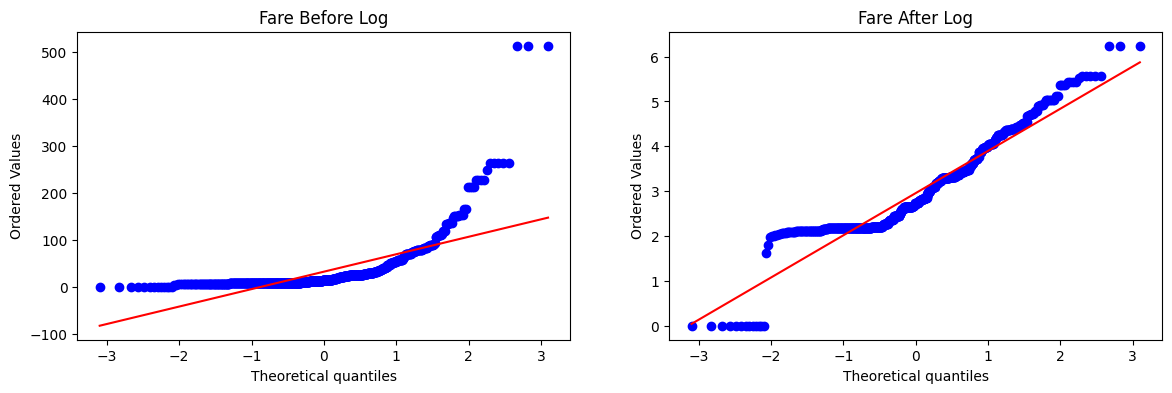

In [61]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

In [67]:
# From above fare plot : after log, line key close agaya hai. that we want.

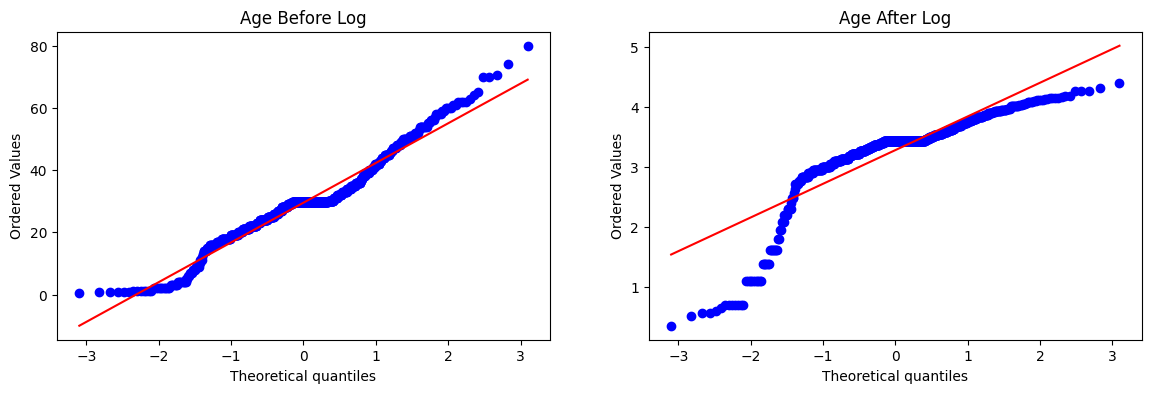

In [66]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [94]:
# Age par log transformation lagnaey sey kaam aur karab ho gaya coz woh phele sey hi normal distributed that but thoda outlier present they 
# humey try kiya li log sey woh problem solve ho but wo nahi hui.
# trial error game.

Abhi hum sirf fare par log use karengey not on Age

In [95]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [101]:
clf = LogisticRegression()
clf2 = RandomForestClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6983240223463687


In [104]:
# Only fare par apply karna aur age par mat karna.

### Don't Belive always on train-test split result for more confirmation use cross validation

In [63]:
# Cross validation : 10 bar train-test split karna and mean accuracy nikalna.

X_transformed2 = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = RandomForestClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("RF",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
RF 0.6824219725343321


In [105]:
# Conclusion : 
# After cross validation  fir sey sabit hogaya ki logistic regression jesey algo par log tranforamtion laganey sey accuracy increase hoti hai.
# aur Random Forest Classifier jesey algo par log transformation laganey sey accuracy par koi farak nahi padta as it is.

##### Making a function of transform and passing various transform as parameter like reciprocal, square, sqrt

In [108]:
def apply_transform(transform):    # Only for fare column.
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

# No tranformation 

Accuracy 0.6589013732833957


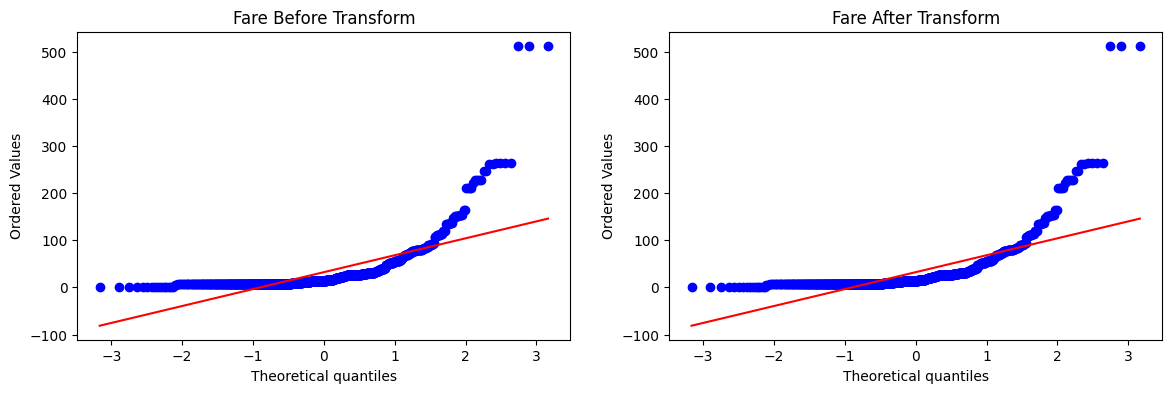

In [107]:
apply_transform( lambda x: x)

# RECIPROCAL TRANSFORM

Accuracy 0.61729088639201


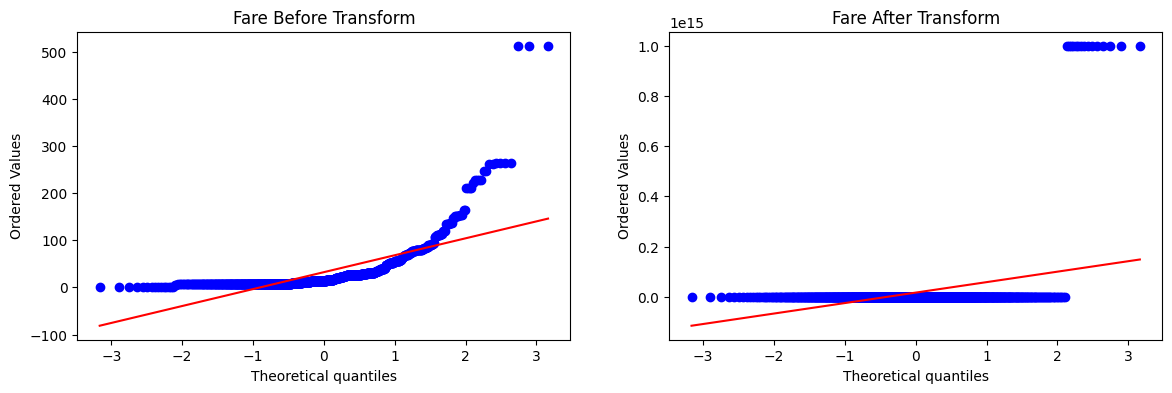

In [117]:
apply_transform( lambda x: 1/(x+0.000000000000001) )  # why +0.1 --> coz fare me 0 bhi hai aur 1/0 is undefined.

In [120]:
# Conclusion : reciprocal sey accuracy decrease hui kyuki data mey zero bhi present hai.
# but agar data mey zero nahi hota to reciprocal transformation accuracy increase kar sakta hai.
# coz big right skewed data. trial error game.

# SQUARE TRANSFORM 

Accuracy 0.6431335830212235


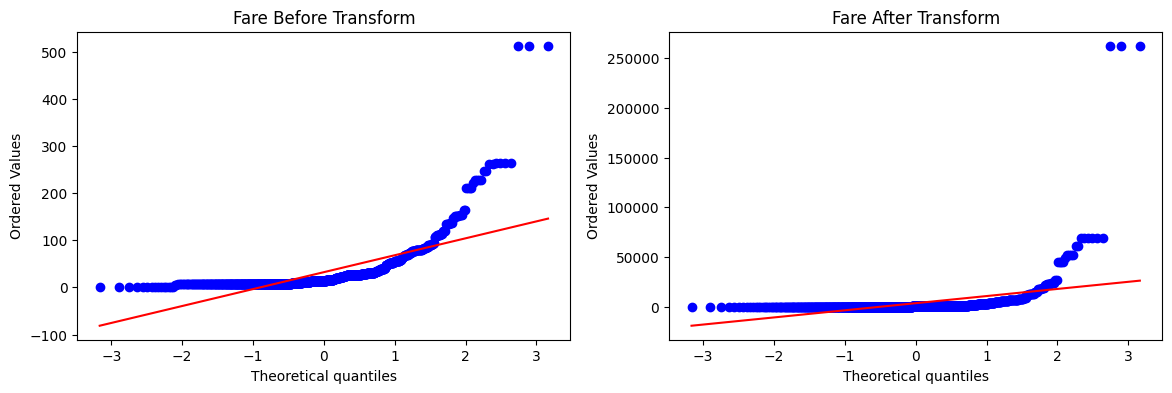

In [121]:
apply_transform( lambda x: x**2)

In [122]:
# Conclusion : accuracy decrease hui kyuki humey square left skewed data par lagna chahiyey tha instead of right skewed data.

# SQUARE ROOT TRANSFORM 

Accuracy 0.6611485642946316


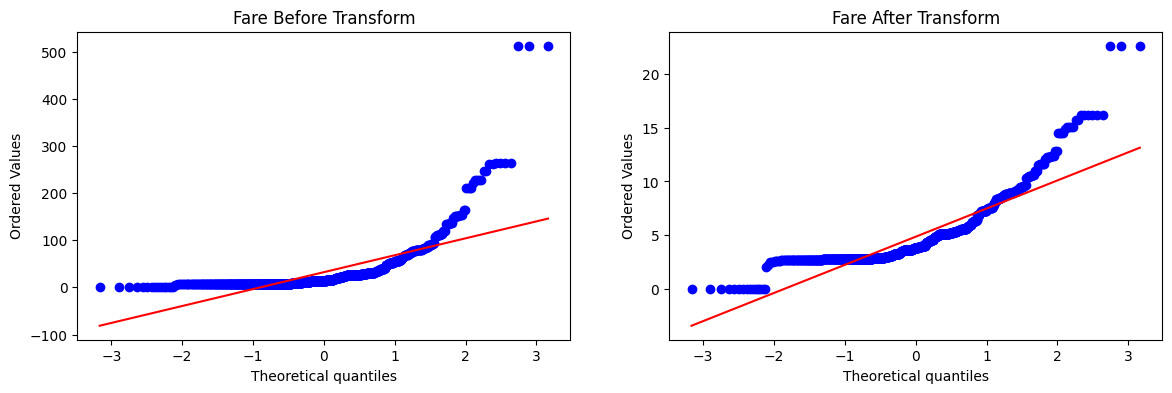

In [123]:
apply_transform( lambda x: x**(1/2))

In [124]:
# Conclusion: still low accuracy 

# OWN TRANSFORM 

Accuracy 0.6195131086142323


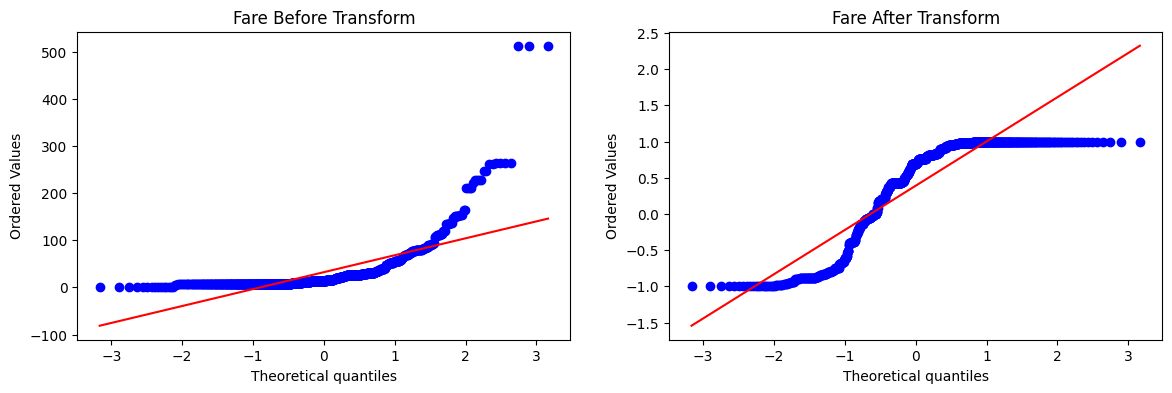

In [125]:
apply_transform(np.sin)

In [126]:
# I know the accuracy is low but I just want to show that we can apply any function as a transformation and see the effect on accuracy.